In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Lindblad Master Equation: Damping Only

Master Equation
$$\frac{dp}{dt}-i [H,\rho] +\Gamma (\sigma_- \rho \sigma_+ -\frac{1}{2}\{\sigma_+ \sigma_- , \rho \}) $$
Initial state:
$$ |\psi(0)> = |1> \implies p(0) = \begin{pmatrix} 0&0 \\ 0&1\end{pmatrix}$$

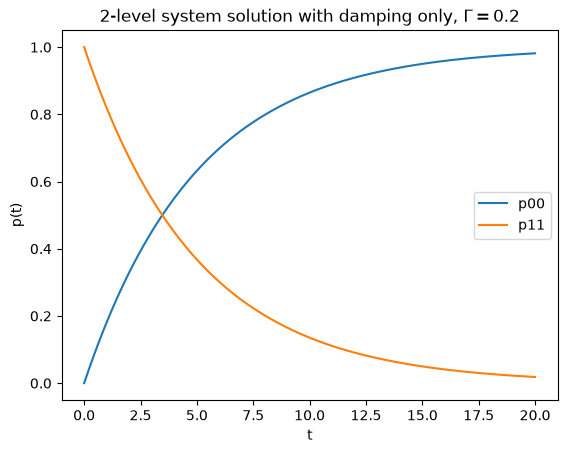

In [45]:
#First, assume H = 0
def p(t,x,gam):
    p00,p01, p10, p11 = x[0], x[1], x[2], x[3]
    dp00 = gam*p11
    dp01 = -gam/2*p01
    dp10 = -gam/2*p10
    dp11 = -gam*p11
    return [dp00, dp01, dp10, dp11]

x0 = [0,0,0,1]
gam = 0.2
sol = solve_ivp(p, [0, 20], x0, args=(gam,), t_eval=np.linspace(0, 20, 100),dense_output=True)



plt.plot(sol.t,sol.y[0],label = 'p00')
plt.plot(sol.t,sol.y[3],label = 'p11')
plt.title(f"2-level system solution with damping only, $\\Gamma = {gam}$")
plt.xlabel('t')
plt.ylabel('p(t)')
plt.legend()
plt.show()

Text(0.5, 1.0, '2-level system solution with damping and oscillation, $\\omega = 1.5, \\Gamma = 0.2$')

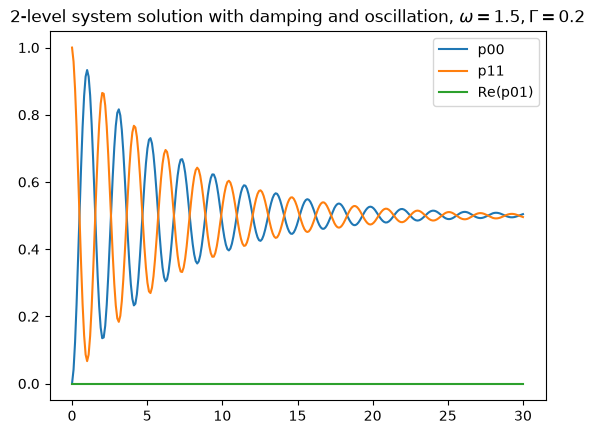

In [46]:
#Now take H = w*sigma_z, sigma_z is the pauli z matrix
def master_eqn(t,x, gam, w):
    p00,p01, p10, p11 = x[0], x[1], x[2], x[3]
    dp00 = gam*p11 + 1j*(p01 - p10)*w
    dp01 = -gam/2*p01 + 1j*(p00 - p11)*w
    dp10 = -gam/2*p10 - 1j*(p00 - p11)*w
    dp11 = -gam*p11 - 1j*(p01 - p10)*w
    return [dp00, dp01, dp10, dp11]

x0 = np.array([0, 0, 0, 1], dtype=complex) 
gam = 0.2
w = 1.5
sol = solve_ivp(master_eqn, [0, 30], x0, args=(gam, w), t_eval=np.linspace(0, 30, 300), dense_output=True)

plt.plot(sol.t, np.real(sol.y[0]), label='p00')
plt.plot(sol.t, np.real(sol.y[3]), label='p11')
plt.plot(sol.t, np.real(sol.y[1]), label='Re(p01)')
plt.legend()
plt.title(f'2-level system solution with damping and oscillation, $\\omega = {w}, \\Gamma = {gam}$')


## Dephasing

Our master equation is:
$$ \frac{dp}{dt}=-i[H,\rho]+\Gamma(\sigma_z \rho \sigma_z - \rho) $$
With initial condition:
$$| \psi_0> = |+> \implies \rho(0) = \begin{pmatrix} 1/2 & 1/2 \\ 1/2 & 1/2\end{pmatrix} $$

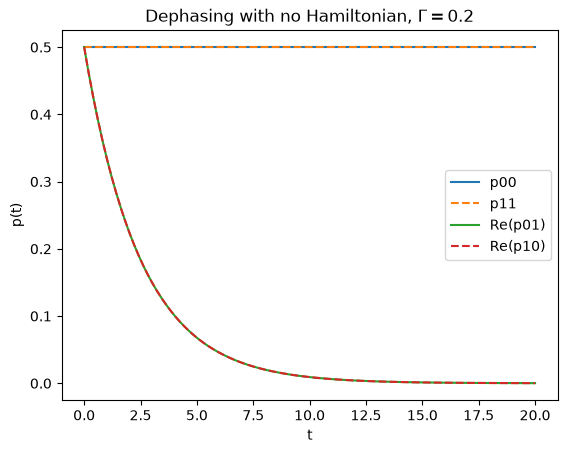

In [47]:
#First, take H = 0
def master_eqn_no_H(t,x, gam):
    p00,p01, p10, p11 = x[0], x[1], x[2], x[3]
    dp00 = 0
    dp01 = -2*gam*p01
    dp10 = -2*gam*p10
    dp11 = 0
    return [dp00, dp01, dp10, dp11]

gam = 0.2

x0 = np.array([1/2, 1/2, 1/2, 1/2], dtype=complex)
sol = solve_ivp(master_eqn_no_H, [0, 20], x0, args=(gam,), t_eval=np.linspace(0, 20, 100), dense_output=True)
plt.plot(sol.t, np.real(sol.y[0]), label='p00')
plt.plot(sol.t, np.real(sol.y[3]),linestyle = "--", label='p11')
plt.plot(sol.t, np.real(sol.y[1]), label='Re(p01)')
plt.plot(sol.t, np.real(sol.y[2]), linestyle = "--", label='Re(p10)')
plt.title(f'Dephasing with no Hamiltonian, $\\Gamma = {gam}$')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.legend()

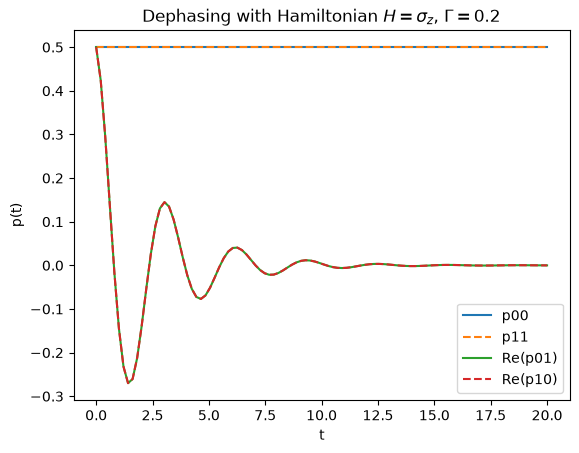

In [ ]:
#Now, take H = sigma_z
def master_eqn_sigma_z(t,x, gam):
    p00,p01, p10, p11 = x[0], x[1], x[2], x[3]
    dp00 = 0
    dp01 = -2*gam*p01 - 2j*p01
    dp10 = -2*gam*p10 + 2j*p10
    dp11 = 0
    return [dp00, dp01, dp10, dp11]

sol= solve_ivp(master_eqn_sigma_z, [0, 20], x0, args=(gam,), t_eval=np.linspace(0, 20, 100), dense_output=True)
plt.plot(sol.t, np.real(sol.y[0]), label='p00')
plt.plot(sol.t, np.real(sol.y[3]),linestyle = "--", label='p11')
plt.plot(sol.t, np.real(sol.y[1]), label='Re(p01)')
plt.plot(sol.t, np.real(sol.y[2]), linestyle = "--", label='Re(p10)')
plt.title(f'Dephasing with Hamiltonian $H = \\sigma_z$, $\\Gamma = {gam}$')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.legend()


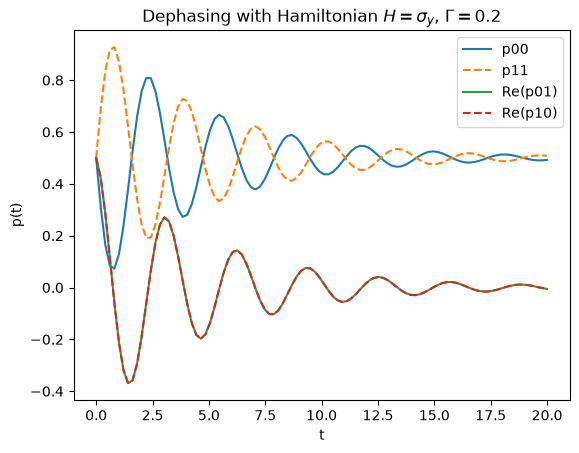

In [ ]:
# master equation for H = sigma_y case
def dpdt(t,x, gam):
    p00,p01, p10, p11 = x[0], x[1], x[2], x[3]
    dp00 = -p01 -p10
    dp01 = p00-2*gam*p01-p11
    dp10 = p00-2*gam*p10-p11
    dp11 = p01 + p10
    return [dp00, dp01, dp10, dp11] 
gam = 0.2
x0 = np.array([1/2, 1/2, 1/2, 1/2], dtype=complex)
sol = solve_ivp(dpdt, [0, 20], x0, args=(gam,), t_eval=np.linspace(0, 20, 100), dense_output=True)
plt.plot(sol.t, np.real(sol.y[0]), label='p00')
plt.plot(sol.t, np.real(sol.y[3]),linestyle = "--", label='p11')
plt.plot(sol.t, np.real(sol.y[1]), label='Re(p01)')
plt.plot(sol.t, np.real(sol.y[2]), linestyle = "--", label='Re(p10)')
plt.title(f'Dephasing with Hamiltonian $H = \\sigma_y$, $\\Gamma = {gam}$')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.legend()

In [ ]:


    p00,p01, p10, p11 = x[0], x[1], x[2], x[3]
    dp00 = -p01 -p10
    dp01 = p00-2*gam*p01-p11
    dp10 = p00-2*gam*p10-p11
    dp11 = p01 + p10
    return [dp00, dp01, dp10, dp1